# 📚 University Library Book Recommendation System
### User-Based Collaborative Filtering — Baseline Model

---

## Problem

A university library gives students access to thousands of books, but with a catalog that large,
students often struggle to discover books that are actually relevant to their interests. There is
currently no personalized way to surface books a given student is likely to enjoy.

## Objective

Build a **personalized book recommendation system** using historical user-book rating data, so that
the library portal can suggest books a student hasn't read yet but is likely to rate highly.

## Approach

We use **Collaborative Filtering** - specifically **User-Based Collaborative Filtering (User-Based CF)**.

The core idea:

```
Similar users  ->  Similar preferences  ->  Books liked by similar users  ->  Recommended to target user
```

The model does not need to understand *what a book is about*. It only needs to learn that users who
have historically rated books similarly are likely to enjoy the same books in the future.

## Datasets

| Dataset | Description |
|---|---|
| `Users.csv` | User demographic information (User-ID, Location, Age) |
| `Ratings.csv` | User -> Book -> Rating interactions (the core dataset) |
| `Books.csv` | Book metadata (Title, Author, Year, Publisher, cover images) |

## Notebook Roadmap

1. Project Introduction
2. Import Libraries
3. Load Datasets
4. Understand the Datasets
5. Exploratory Data Analysis (EDA)
6. Data Cleaning
7. Understand Rating Semantics
8. Merge Datasets
9. Analyze Sparsity
10. Handle Sparsity
11. Create the User-Book Interaction Matrix
12. Train / Test Split
13. Build User-Based Collaborative Filtering Model
14. Calculate User Similarity
15. Generate Recommendations
16. Evaluate the Model
17. Test With Real Users
18. Display Book Information
19. Limitations
20. Conclusion

Every threshold and number in this notebook is **derived from the actual data** rather than assumed
up front - we inspect distributions before deciding cutoffs, and we measure accuracy rather than
declaring the system "works" by inspection.

## 2. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import coo_matrix
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. Load the Three Datasets

We load `Users.csv`, `Ratings.csv`, and `Books.csv` and immediately confirm their shapes rather than
assuming them.

In [ ]:
DATA_DIR = "/content"

users = pd.read_csv(f"{DATA_DIR}/Users.csv")
ratings = pd.read_csv(f"{DATA_DIR}/Ratings.csv")
books = pd.read_csv(f"{DATA_DIR}/Books.csv")

print(f"Users.csv   -> {users.shape[0]:,} rows x {users.shape[1]} columns")
print(f"Ratings.csv -> {ratings.shape[0]:,} rows x {ratings.shape[1]} columns")
print(f"Books.csv   -> {books.shape[0]:,} rows x {books.shape[1]} columns")

Users.csv   -> 278,858 rows x 3 columns
Ratings.csv -> 1,149,780 rows x 3 columns
Books.csv   -> 271,360 rows x 8 columns


## 4. Understand Each Dataset

- **Users** -> identifies each user (`User-ID`); `Location`/`Age` are optional demographic extras, not
  required for the baseline collaborative filtering model.
- **Ratings** -> the core dataset: `User-ID -> ISBN -> Book-Rating`.
- **Books** -> lets us turn an `ISBN` into something human-readable (title, author, year, publisher).

The three datasets connect through:

```
Users.User-ID -> Ratings.User-ID      Ratings.ISBN -> Books.ISBN
```

In [ ]:
print("USERS"); display(users.head())
print("\nRATINGS"); display(ratings.head())
print("\nBOOKS"); display(books.head())

USERS


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN



RATINGS


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6



BOOKS


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [ ]:
print("Users dtypes:\n", users.dtypes, "\n")
print("Ratings dtypes:\n", ratings.dtypes, "\n")
print("Books dtypes:\n", books.dtypes)

Users dtypes:
 User-ID       int64
Location     object
Age         float64
dtype: object 

Ratings dtypes:
 User-ID         int64
ISBN           object
Book-Rating     int64
dtype: object 

Books dtypes:
 ISBN                   object
Book-Title             object
Book-Author            object
Year-Of-Publication    object
Publisher              object
Image-URL-S            object
Image-URL-M            object
Image-URL-L            object
dtype: object


## 5. Exploratory Data Analysis (EDA)

Before changing anything, we look at what we're actually working with: how active users are, how
popular books are, and what the rating values look like.

### 5.1 Users

In [ ]:
print(f"Unique users: {users['User-ID'].nunique():,}")
print(f"Users with known Age: {users['Age'].notna().sum():,} ({users['Age'].notna().mean()*100:.1f}%)")
print(f"Unique locations: {users['Location'].nunique():,}")
print("\nAge summary (raw, before cleaning):")
print(users['Age'].describe())

Unique users: 278,858
Users with known Age: 168,096 (60.3%)
Unique locations: 57,339

Age summary (raw, before cleaning):
count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64


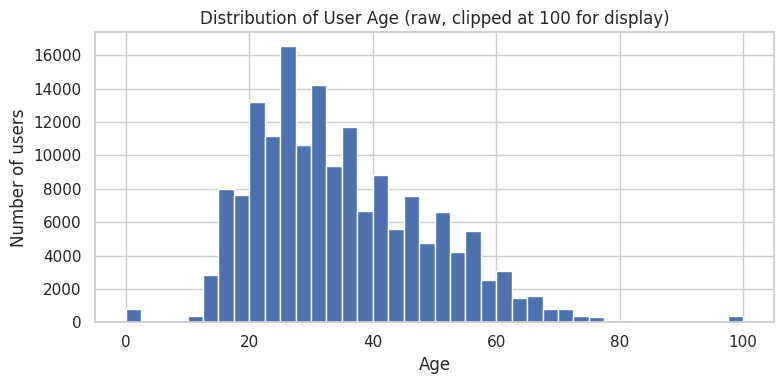

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
users['Age'].dropna().clip(upper=100).hist(bins=40, ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of User Age (raw, clipped at 100 for display)')
ax.set_xlabel('Age'); ax.set_ylabel('Number of users')
plt.tight_layout(); plt.show()

### 5.2 Ratings

In [ ]:
print(f"Total interactions: {len(ratings):,}")
print(f"Unique users who rated something: {ratings['User-ID'].nunique():,}")
print(f"Unique books rated: {ratings['ISBN'].nunique():,}")

zero_ratings = (ratings['Book-Rating'] == 0).sum()
explicit_ratings = (ratings['Book-Rating'] > 0).sum()
print(f"\nZero ratings (Book-Rating == 0): {zero_ratings:,} ({zero_ratings/len(ratings)*100:.1f}%)")
print(f"Explicit ratings (Book-Rating 1-10): {explicit_ratings:,} ({explicit_ratings/len(ratings)*100:.1f}%)")

Total interactions: 1,149,780
Unique users who rated something: 105,283
Unique books rated: 340,556

Zero ratings (Book-Rating == 0): 716,109 (62.3%)
Explicit ratings (Book-Rating 1-10): 433,671 (37.7%)


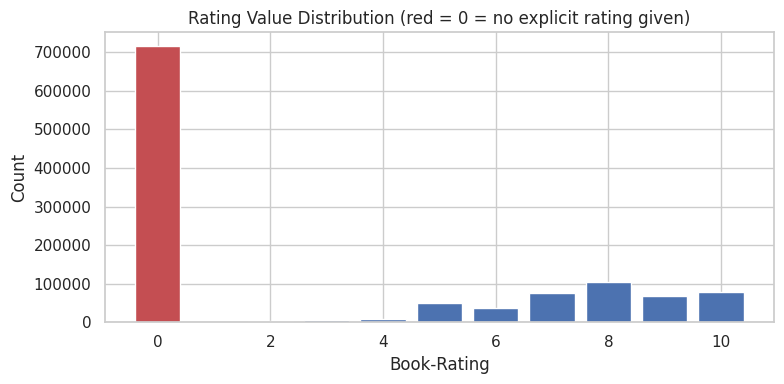

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
rating_counts = ratings['Book-Rating'].value_counts().sort_index()
colors = ['#C44E52' if r == 0 else '#4C72B0' for r in rating_counts.index]
ax.bar(rating_counts.index, rating_counts.values, color=colors)
ax.set_title('Rating Value Distribution (red = 0 = no explicit rating given)')
ax.set_xlabel('Book-Rating'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

**Important:** in the Book-Crossing dataset, `Book-Rating == 0` does not mean "the user hated this
book" - it means the user interacted with the book but never gave it an explicit 1-10 score. We must
not treat `0` as a negative rating. This is handled explicitly in Section 7.

### 5.3 Books

In [ ]:
print(f"Unique books: {books['ISBN'].nunique():,}")
print(f"Duplicate ISBNs: {books['ISBN'].duplicated().sum():,}")
print(f"Missing Book-Author: {books['Book-Author'].isna().sum()}")
print(f"Missing Publisher: {books['Publisher'].isna().sum()}")
print(f"Missing Book-Title: {books['Book-Title'].isna().sum()}")

top_authors = books['Book-Author'].value_counts().head(10)
print("\nTop 10 most-published authors (by catalog count):")
print(top_authors)

Unique books: 271,360
Duplicate ISBNs: 0
Missing Book-Author: 2
Missing Publisher: 2
Missing Book-Title: 0

Top 10 most-published authors (by catalog count):
Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: count, dtype: int64


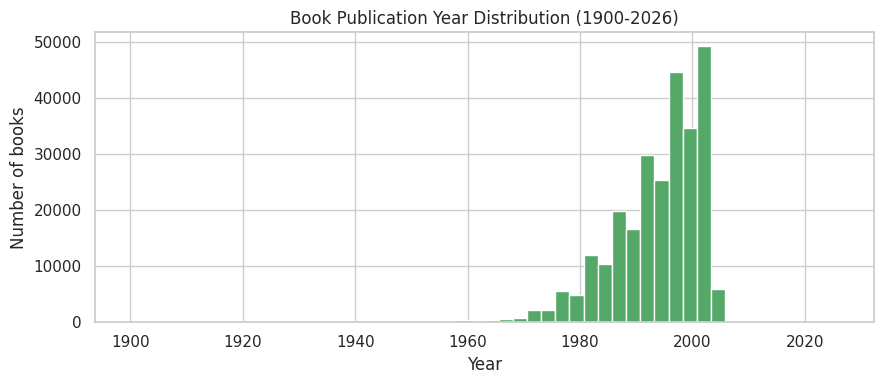

Rows where Year-Of-Publication is not numeric at all: 3


In [ ]:
years_numeric = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
valid_years = years_numeric[(years_numeric >= 1900) & (years_numeric <= 2026)]

fig, ax = plt.subplots(figsize=(9, 4))
valid_years.hist(bins=50, ax=ax, color='#55A868', edgecolor='white')
ax.set_title('Book Publication Year Distribution (1900-2026)')
ax.set_xlabel('Year'); ax.set_ylabel('Number of books')
plt.tight_layout(); plt.show()

n_invalid = years_numeric.isna().sum()
print(f"Rows where Year-Of-Publication is not numeric at all: {n_invalid}")

### 5.4 Ratings per user & per book (raw, before any cleaning)

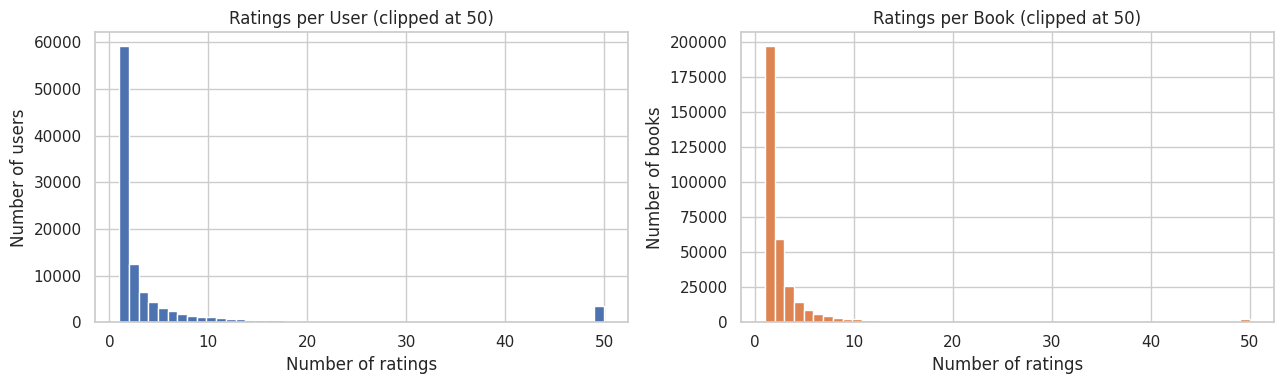

Ratings-per-user percentiles:
count    105283.000000
mean         10.920851
std          90.562825
min           1.000000
50%           1.000000
75%           4.000000
90%          12.000000
95%          29.000000
99%         174.000000
max       13602.000000
dtype: float64

Ratings-per-book percentiles:
count    340556.000000
mean          3.376185
std          12.436252
min           1.000000
50%           1.000000
75%           2.000000
90%           6.000000
95%          10.000000
99%          36.000000
max        2502.000000
dtype: float64


In [ ]:
ratings_per_user_raw = ratings.groupby('User-ID').size()
ratings_per_book_raw = ratings.groupby('ISBN').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(ratings_per_user_raw.clip(upper=50), bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Ratings per User (clipped at 50)')
axes[0].set_xlabel('Number of ratings'); axes[0].set_ylabel('Number of users')

axes[1].hist(ratings_per_book_raw.clip(upper=50), bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('Ratings per Book (clipped at 50)')
axes[1].set_xlabel('Number of ratings'); axes[1].set_ylabel('Number of books')
plt.tight_layout(); plt.show()

print("Ratings-per-user percentiles:")
print(ratings_per_user_raw.describe(percentiles=[.5, .75, .9, .95, .99]))
print("\nRatings-per-book percentiles:")
print(ratings_per_book_raw.describe(percentiles=[.5, .75, .9, .95, .99]))

Both distributions are heavily right-skewed - the median user/book has very few interactions, while
a small number of very active users / very popular books account for a disproportionate share of the
data. This is the classic **long-tail** pattern, and it's exactly why sparsity (Sections 9-10) is
going to need real attention.

## 6. Data Cleaning

Now that we understand what's in each dataset, we clean each one deliberately - fixing what's broken,
without over-processing columns the baseline model doesn't even need.

### 6.1 Clean `Books.csv`

Loading `Books.csv` triggers a pandas *"mixed types"* warning on `Year-Of-Publication`. Let's find out
exactly why.

In [ ]:
def is_numeric(x):
    try:
        float(x); return True
    except (TypeError, ValueError):
        return False

non_numeric_mask = ~books['Year-Of-Publication'].astype(str).apply(is_numeric)
print(f"Rows with non-numeric Year-Of-Publication: {non_numeric_mask.sum()}")
display(books.loc[non_numeric_mask])

Rows with non-numeric Year-Of-Publication: 3


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


These rows have their columns shifted - the `Book-Title` field contains an unescaped quote in the
original CSV, which pushed `Author`/`Year`/`Publisher` into the wrong columns. There are only 3 such
rows out of 271,360, so we drop them rather than trying to realign shifted columns for so few records.

In [ ]:
BAD_ISBNS = ['078946697X', '2070426769', '0789466953']
books_clean = books[~books['ISBN'].isin(BAD_ISBNS)].copy()

books_clean['Year-Of-Publication'] = pd.to_numeric(books_clean['Year-Of-Publication'], errors='coerce')

CURRENT_YEAR = 2026
invalid_year_mask = (books_clean['Year-Of-Publication'] < 1450) | (books_clean['Year-Of-Publication'] > CURRENT_YEAR)
print(f"Implausible publication years (before 1450 or after {CURRENT_YEAR}): {invalid_year_mask.sum()}")
books_clean.loc[invalid_year_mask, 'Year-Of-Publication'] = np.nan

books_clean['Book-Author'] = books_clean['Book-Author'].fillna('Unknown')
books_clean['Publisher'] = books_clean['Publisher'].fillna('Unknown')
books_clean = books_clean.drop_duplicates(subset=['ISBN'])

print(f"\nBooks.csv: {len(books)} -> {len(books_clean)} rows after cleaning")

Implausible publication years (before 1450 or after 2026): 4631

Books.csv: 271360 -> 271357 rows after cleaning


### 6.2 Clean `Users.csv`

We don't need to fill every missing `Age` - it isn't used by the baseline collaborative filtering
model at all. We only clip clearly-impossible ages (the raw data goes up to 244).

In [ ]:
users_clean = users.drop_duplicates(subset=['User-ID']).copy()

invalid_age_mask = (users_clean['Age'] < 5) | (users_clean['Age'] > 100)
print(f"Implausible ages (below 5 or above 100): {invalid_age_mask.sum()}")
users_clean.loc[invalid_age_mask, 'Age'] = np.nan

print(f"\nUsers.csv: {len(users)} -> {len(users_clean)} rows after cleaning")
print(f"Age still missing/invalid: {users_clean['Age'].isna().sum():,} ({users_clean['Age'].isna().mean()*100:.1f}%) - left as NaN, not needed for the baseline model")

Implausible ages (below 5 or above 100): 1248

Users.csv: 278858 -> 278858 rows after cleaning
Age still missing/invalid: 112,010 (40.2%) - left as NaN, not needed for the baseline model


### 6.3 Clean `Ratings.csv`

We check for duplicate `(User-ID, ISBN)` pairs - the same user rating the same book twice would
distort both the interaction matrix and evaluation.

In [ ]:
dup_mask = ratings.duplicated(subset=['User-ID', 'ISBN'])
print(f"Duplicate (User-ID, ISBN) pairs: {dup_mask.sum()}")

ratings_clean = ratings.drop_duplicates(subset=['User-ID', 'ISBN']).copy()
print(f"Ratings.csv: {len(ratings)} -> {len(ratings_clean)} rows after cleaning")

Duplicate (User-ID, ISBN) pairs: 0
Ratings.csv: 1149780 -> 1149780 rows after cleaning


## 7. Understand Rating Semantics

As established in Section 5.2: `Book-Rating == 0` means *"no explicit rating was given"*, not
*"the user disliked this book."* For a baseline **explicit-rating** collaborative filtering model, we
keep only the explicit ratings (1-10) and drop the implicit (0) interactions - we never treat a
missing/implicit interaction as a negative signal.

In [ ]:
explicit = ratings_clean[ratings_clean['Book-Rating'] > 0].copy()
implicit = ratings_clean[ratings_clean['Book-Rating'] == 0].copy()

print(f"Explicit ratings (kept for modeling): {len(explicit):,}")
print(f"Implicit / zero interactions (set aside): {len(implicit):,}")
print(f"Unique users with an explicit rating: {explicit['User-ID'].nunique():,}")
print(f"Unique books with an explicit rating: {explicit['ISBN'].nunique():,}")

Explicit ratings (kept for modeling): 433,671
Implicit / zero interactions (set aside): 716,109
Unique users with an explicit rating: 77,805
Unique books with an explicit rating: 185,973


## 8. Merge the Datasets

Our relationship chain is `Users.User-ID -> Ratings.User-ID -> Ratings.ISBN -> Books.ISBN`.

Before building the interaction matrix, we inner-join the explicit ratings against `Books.csv` so
that every interaction we model has real book metadata behind it. This also has a side effect worth
checking explicitly: **some ISBNs that appear in `Ratings.csv` don't exist in `Books.csv` at all**
(likely data-entry inconsistencies in the original source). We measure this rather than assume it
away.

In [ ]:
orphan_mask = ~explicit['ISBN'].isin(books_clean['ISBN'])
print(f"Explicit ratings referencing an ISBN missing from Books.csv: {orphan_mask.sum():,} "
      f"({orphan_mask.mean()*100:.2f}% of explicit ratings)")

merged = explicit.merge(books_clean[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']],
                          on='ISBN', how='inner')

print(f"\nExplicit ratings: {len(explicit):,} -> {len(merged):,} after keeping only ISBNs with valid book metadata")
display(merged.head())

Explicit ratings referencing an ISBN missing from Books.csv: 49,830 (11.49% of explicit ratings)

Explicit ratings: 433,671 -> 383,841 after keeping only ISBNs with valid book metadata


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276726,0155061224,5,Rites of Passage,Judith Rae,2001.0,Heinle
1,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press
2,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press
3,276744,038550120X,7,A Painted House,JOHN GRISHAM,2001.0,Doubleday
4,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells,2003.0,HarperTorch


## 9. Analyze Sparsity

The theoretical user-item matrix would be `(unique users) x (unique books)`. Let's see how full that
matrix would actually be.

In [ ]:
n_users_all = merged['User-ID'].nunique()
n_books_all = merged['ISBN'].nunique()
n_interactions = len(merged)
possible_cells = n_users_all * n_books_all
density_all = n_interactions / possible_cells

print(f"Users with >=1 explicit, valid rating: {n_users_all:,}")
print(f"Books with >=1 explicit, valid rating: {n_books_all:,}")
print(f"Possible (user, book) cells: {possible_cells:,}")
print(f"Actual filled cells (interactions): {n_interactions:,}")
print(f"Matrix density: {density_all*100:.4f}%  ->  {100 - density_all*100:.4f}% empty")

Users with >=1 explicit, valid rating: 68,091
Books with >=1 explicit, valid rating: 149,835
Possible (user, book) cells: 10,202,414,985
Actual filled cells (interactions): 383,841
Matrix density: 0.0038%  ->  99.9962% empty


A matrix this size and this empty (over 99.9% empty) is both computationally wasteful to store
densely and statistically unreliable at the edges - a user with 1 rating or a book with 1 rating gives
the similarity calculation almost no real signal. Section 10 addresses both problems.

## 10. Handle Sparsity

We use three strategies, and we pick the thresholds from the actual distribution rather than
guessing a round number.

**Strategy A + B — filter inactive users and unpopular books.** We look at the ratings-per-user and
ratings-per-book distribution *within the merged, explicit data* and choose thresholds accordingly.

In [ ]:
ratings_per_user = merged.groupby('User-ID').size()
ratings_per_book = merged.groupby('ISBN').size()

print("Ratings-per-user percentiles (explicit, merged data):")
print(ratings_per_user.describe(percentiles=[.5, .75, .9, .95, .99]))
print("\nRatings-per-book percentiles (explicit, merged data):")
print(ratings_per_book.describe(percentiles=[.5, .75, .9, .95, .99]))

print("\nUsers retained at each candidate threshold:")
for th in [3, 5, 8, 10, 15, 20]:
    print(f"  >= {th} ratings: {(ratings_per_user >= th).sum():,} users")
print("\nBooks retained at each candidate threshold:")
for th in [3, 5, 8, 10, 15, 20]:
    print(f"  >= {th} ratings: {(ratings_per_book >= th).sum():,} books")

Ratings-per-user percentiles (explicit, merged data):
count    68091.000000
mean         5.637177
std         41.742508
min          1.000000
50%          1.000000
75%          3.000000
90%          9.000000
95%         19.000000
99%         74.100000
max       6943.000000
dtype: float64

Ratings-per-book percentiles (explicit, merged data):
count    149835.000000
mean          2.561758
std           7.505586
min           1.000000
50%           1.000000
75%           2.000000
90%           4.000000
95%           7.000000
99%          24.000000
max         707.000000
dtype: float64

Users retained at each candidate threshold:
  >= 3 ratings: 20,194 users
  >= 5 ratings: 12,787 users
  >= 8 ratings: 8,216 users
  >= 10 ratings: 6,589 users
  >= 15 ratings: 4,458 users
  >= 20 ratings: 3,305 users

Books retained at each candidate threshold:
  >= 3 ratings: 27,804 books
  >= 5 ratings: 13,787 books
  >= 8 ratings: 7,308 books
  >= 10 ratings: 5,444 books
  >= 15 ratings: 3,151 books
  >=

We choose **`min_user_ratings = 5`** and **`min_book_ratings = 5`**: it keeps a meaningfully large,
active slice of the data (the median user/book has only 1-2 ratings, so this already trims a lot of
the unreliable long tail) while remaining computationally manageable for a baseline model. This is a
tunable hyperparameter, not a hard rule - Section 19 revisits what happens if it's changed.

Filtering by user count changes which books qualify and vice versa, so we filter **iteratively** until
the dataset stabilizes.

In [ ]:
MIN_USER_RATINGS = 5
MIN_BOOK_RATINGS = 5

def iterative_filter(df, min_user_ratings, min_book_ratings, max_iter=10):
    '''Repeatedly drop low-activity users/books until neither changes the dataset further.'''
    for _ in range(max_iter):
        before = len(df)
        uc = df['User-ID'].value_counts()
        df = df[df['User-ID'].isin(uc[uc >= min_user_ratings].index)]
        bc = df['ISBN'].value_counts()
        df = df[df['ISBN'].isin(bc[bc >= min_book_ratings].index)]
        if len(df) == before:
            break
    return df

filtered = iterative_filter(merged, MIN_USER_RATINGS, MIN_BOOK_RATINGS)

n_users_f = filtered['User-ID'].nunique()
n_books_f = filtered['ISBN'].nunique()
density_f = len(filtered) / (n_users_f * n_books_f)

print(f"After filtering: {len(filtered):,} interactions, {n_users_f:,} users, {n_books_f:,} books")
print(f"New matrix density: {density_f*100:.3f}%  (was {density_all*100:.4f}% before filtering)")

After filtering: 115,219 interactions, 6,851 users, 9,085 books
New matrix density: 0.185%  (was 0.0038% before filtering)


**Strategy C — minimum common books for similarity.** Two users who share only *one* rated book
aren't reliable evidence of similarity (they could match by coincidence). We'll enforce a minimum
number of commonly-rated books before trusting a similarity score between two users - implemented in
Section 13, once we have the interaction matrix built.

**Strategy D — sparse matrix representation.** Even after filtering, we never materialize a dense
`users x books` array full of NaNs. We store only the actual ratings using `scipy.sparse`, built in
Section 11.

## 11. Create the User-Book Interaction Matrix

We map each surviving `User-ID` and `ISBN` to a dense integer index (0..N-1), which is what
`scipy.sparse` needs internally.

In [ ]:
user_ids = filtered['User-ID'].unique()
book_isbns = filtered['ISBN'].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
book2idx = {b: i for i, b in enumerate(book_isbns)}
idx2user = {i: u for u, i in user2idx.items()}
idx2book = {i: b for b, i in book2idx.items()}

n_users = len(user_ids)
n_books = len(book_isbns)
print(f"Working matrix: {n_users:,} users x {n_books:,} books")

Working matrix: 6,851 users x 9,085 books


We build the matrix later (Section 13) from the **training split only**, so we do the train/test
split first.

## 12. Train / Test Split

A plain random 80/20 split can strand a user entirely in the test set if all of their ratings happen
to land there - leaving nothing in training to base a recommendation on. Instead we split **per
user**: each user contributes roughly 20% of *their own* ratings to the test set, and at least one
rating always stays in training.

In [ ]:
TEST_FRACTION = 0.2

rng = np.random.default_rng(RANDOM_SEED)
train_parts, test_parts = [], []

for uid, group in filtered.groupby('User-ID'):
    idxs = group.index.to_numpy().copy()
    rng.shuffle(idxs)
    n_test = int(round(TEST_FRACTION * len(idxs)))
    n_test = min(max(1, n_test), len(idxs) - 1)  # at least 1 test, at least 1 train
    test_parts.append(filtered.loc[idxs[:n_test]])
    train_parts.append(filtered.loc[idxs[n_test:]])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print(f"Train: {len(train_df):,} interactions")
print(f"Test:  {len(test_df):,} interactions")
print(f"Every user has training data: {train_df['User-ID'].nunique() == n_users}")

Train: 92,414 interactions
Test:  22,805 interactions
Every user has training data: True


## 13. Build the User-Based Collaborative Filtering Model

**A note on terminology:** this isn't supervised learning in the `model.fit(X, y)` sense. We're not
training a neural network - we're computing relationships directly from the user-item interaction
matrix (user similarity -> neighbor ratings -> recommendation scores). It's correct to call this a
**Collaborative Filtering Recommendation Model**.

**Mean-centering.** Some users rate everything generously (an "8" is their average), others are
harsher (a "5" is generous for them). To compare rating *patterns* rather than absolute scale, we
subtract each user's own average rating from their ratings before computing similarity - so a user's
vector reflects "better/worse than their own average" rather than raw scores.

In [ ]:
user_means = train_df.groupby('User-ID')['Book-Rating'].mean()
train_df['centered_rating'] = train_df['Book-Rating'] - train_df['User-ID'].map(user_means)

rows = train_df['User-ID'].map(user2idx).to_numpy()
cols = train_df['ISBN'].map(book2idx).to_numpy()
vals = train_df['centered_rating'].to_numpy()

train_matrix = coo_matrix((vals, (rows, cols)), shape=(n_users, n_books)).tocsr()

# A parallel binary (1 = rated, 0 = not rated) matrix - used for co-rating counts and weighting.
binary_matrix = train_matrix.copy()
binary_matrix.data = np.ones_like(binary_matrix.data)

print(f"Sparse training matrix: shape={train_matrix.shape}, stored entries={train_matrix.nnz:,}")
print(f"Density: {train_matrix.nnz / (n_users * n_books) * 100:.3f}%")
print(f"Memory if this were a dense float64 array: {n_users * n_books * 8 / 1e9:.2f} GB")
print(f"Actual memory as a sparse CSR matrix: {(train_matrix.data.nbytes + train_matrix.indices.nbytes + train_matrix.indptr.nbytes) / 1e6:.2f} MB")

Sparse training matrix: shape=(6851, 9085), stored entries=92,414
Density: 0.148%
Memory if this were a dense float64 array: 0.50 GB
Actual memory as a sparse CSR matrix: 1.14 MB


## 14. Calculate User Similarity

We use **cosine similarity** between user rating vectors (on the centered, sparse matrix).
`sklearn.metrics.pairwise.cosine_similarity` works directly on sparse input, which is exactly what we
need given the matrix size.

Then we enforce the **minimum common books** rule from Section 10: if two users share fewer than
`MIN_COMMON_BOOKS` co-rated books, we zero out their similarity - it isn't trustworthy evidence.

In [ ]:
similarity_matrix = cosine_similarity(train_matrix)

# Co-rating counts: how many books did each pair of users both rate?
co_rating_counts = (binary_matrix @ binary_matrix.T).toarray()

MIN_COMMON_BOOKS = 2
similarity_masked = similarity_matrix.copy()
similarity_masked[co_rating_counts < MIN_COMMON_BOOKS] = 0
np.fill_diagonal(similarity_masked, 0)  # a user is never their own neighbor

print(f"Similarity matrix shape: {similarity_masked.shape}")
print(f"Average non-zero similarity pairs per user: {(similarity_masked > 0).sum(axis=1).mean():.1f}")

# Sanity check: show the most similar users to a sample user
sample_idx = 0
top5 = np.argsort(-similarity_masked[sample_idx])[:5]
print(f"\nTop 5 most similar users to User {idx2user[sample_idx]}:")
for i in top5:
    print(f"  User {idx2user[i]}  similarity={similarity_masked[sample_idx, i]:.3f}  "
          f"(shares {int(co_rating_counts[sample_idx, i])} co-rated books)")

Similarity matrix shape: (6851, 6851)
Average non-zero similarity pairs per user: 19.6

Top 5 most similar users to User 276964:
  User 261603  similarity=0.098  (shares 2 co-rated books)
  User 227520  similarity=0.010  (shares 2 co-rated books)
  User 136382  similarity=0.005  (shares 2 co-rated books)
  User 81560  similarity=0.004  (shares 3 co-rated books)
  User 183572  similarity=0.000  (shares 0 co-rated books)


## 15. Generate Recommendations

For a target user we:

1. Take their **top-K most similar users** (the "neighborhood") whose similarity survived the
   minimum-common-books filter.
2. For every candidate book any neighbor rated, compute a **similarity-weighted average** of the
   neighbors' (centered) ratings.
3. Add back the target user's own average rating (undoing the centering from Section 13).
4. **Remove books the user has already rated** - we never recommend something they've already read.
5. Rank the remaining candidates and return the Top-N.

In [ ]:
K_NEIGHBORS = 20

user_means_arr = np.array([user_means.get(idx2user[i], 0.0) for i in range(n_users)])

def get_topk_neighbor_vector(u_idx, k=K_NEIGHBORS):
    '''Return a length-n_users vector that is zero everywhere except the top-k similar,
    trustworthy neighbors of user u_idx (their similarity score is kept as the weight).'''
    row = similarity_masked[u_idx]
    if not np.any(row > 0):
        return None
    top_idx = np.argpartition(-row, min(k, len(row) - 1))[:k]
    top_idx = top_idx[row[top_idx] > 0]
    if len(top_idx) == 0:
        return None
    vec = np.zeros(n_users)
    vec[top_idx] = row[top_idx]
    return vec

def predict_ratings_for_user(u_idx):
    '''Predicted rating for every book, for one user. NaN where no neighbor covers that book.'''
    neighbor_vec = get_topk_neighbor_vector(u_idx)
    if neighbor_vec is None:
        return None
    numerator = np.asarray(neighbor_vec @ train_matrix).ravel()
    denominator = np.asarray(np.abs(neighbor_vec) @ binary_matrix).ravel()
    predicted_centered = np.divide(numerator, denominator,
                                    out=np.full_like(numerator, np.nan), where=denominator > 0)
    predicted = predicted_centered + user_means_arr[u_idx]
    return np.clip(predicted, 1, 10)

def recommend_for_user(u_idx, top_n=10):
    '''Top-N book recommendations for one user, as a DataFrame with titles/authors/scores.'''
    pred = predict_ratings_for_user(u_idx)
    if pred is None:
        return None
    uid = idx2user[u_idx]
    already_rated = set(train_df.loc[train_df['User-ID'] == uid, 'ISBN'])
    already_idx = [book2idx[isbn] for isbn in already_rated if isbn in book2idx]

    candidate_scores = pred.copy()
    candidate_scores[already_idx] = np.nan
    valid = ~np.isnan(candidate_scores)
    if valid.sum() == 0:
        return None

    order = np.argsort(-np.where(valid, candidate_scores, -np.inf))[:top_n]
    isbns = [idx2book[i] for i in order]
    scores = candidate_scores[order]

    result = books_clean[books_clean['ISBN'].isin(isbns)][['ISBN', 'Book-Title', 'Book-Author']].copy()
    score_map = dict(zip(isbns, scores))
    result['Predicted-Score'] = result['ISBN'].map(score_map)
    return result.sort_values('Predicted-Score', ascending=False).reset_index(drop=True)

print("Recommendation functions ready.")

Recommendation functions ready.


## 16. Evaluate the Model

We don't just assume the model "works" - we measure it two different ways, because they answer two
different questions.

**A. Rating prediction accuracy (RMSE / MAE)** - "how close is the predicted score to the actual
score?" We precompute every user's full prediction row once, then look up the predicted rating for
each held-out test interaction.

In [ ]:
all_predictions = {u: predict_ratings_for_user(u) for u in range(n_users)}
covered_users = sum(1 for v in all_predictions.values() if v is not None)
print(f"Users with at least one usable neighbor: {covered_users:,} / {n_users:,} "
      f"({covered_users/n_users*100:.1f}%)")

Users with at least one usable neighbor: 5,796 / 6,851 (84.6%)


In [ ]:
test_eval = test_df.copy()
test_eval['u_idx'] = test_eval['User-ID'].map(user2idx)
test_eval['b_idx'] = test_eval['ISBN'].map(book2idx)

u_arr = test_eval['u_idx'].to_numpy()
b_arr = test_eval['b_idx'].to_numpy()
actual_arr = test_eval['Book-Rating'].to_numpy(dtype=float)

predicted_arr = np.full(len(test_eval), np.nan)
for i in range(len(test_eval)):
    row = all_predictions[u_arr[i]]
    if row is not None:
        predicted_arr[i] = row[b_arr[i]]

evaluable = ~np.isnan(predicted_arr)
print(f"Test interactions we could actually predict for: {evaluable.sum():,} / {len(test_eval):,} "
      f"({evaluable.mean()*100:.1f}%)")

errors = predicted_arr[evaluable] - actual_arr[evaluable]
rmse = np.sqrt(np.mean(errors ** 2))
mae = np.mean(np.abs(errors))
print(f"\nRMSE = {rmse:.3f}   (on a 1-10 rating scale)")
print(f"MAE  = {mae:.3f}")

Test interactions we could actually predict for: 5,998 / 22,805 (26.3%)

RMSE = 1.843   (on a 1-10 rating scale)
MAE  = 1.344


**B. Top-N recommendation quality (Precision@K / Recall@K)** - the library portal will never say
*"we predict you'd rate this 8.7"*; it will say *"here are 10 books you might like."* So we also
measure: of the books we recommend, how many did the user actually rate highly in the held-out test
set (and of the books they rated highly, how many did we manage to surface)?

In [ ]:
TOP_N = 10
RELEVANT_THRESHOLD = 7  # a held-out rating >= 7 counts as "the user liked this book"

train_rated_by_user = train_df.groupby('User-ID')['ISBN'].apply(set)
test_relevant_by_user = test_df[test_df['Book-Rating'] >= RELEVANT_THRESHOLD].groupby('User-ID')['ISBN'].apply(set)

precisions, recalls = [], []
for u_idx in range(n_users):
    uid = idx2user[u_idx]
    relevant = test_relevant_by_user.get(uid, set())
    if not relevant:
        continue  # can't measure recall/precision for a user with no "liked" test items

    pred = all_predictions[u_idx]
    if pred is None:
        continue

    already_idx = [book2idx[i] for i in train_rated_by_user.get(uid, set()) if i in book2idx]
    candidates = pred.copy()
    candidates[already_idx] = np.nan
    valid = ~np.isnan(candidates)
    if valid.sum() == 0:
        continue

    top_order = np.argsort(-np.where(valid, candidates, -np.inf))[:TOP_N]
    recommended = {idx2book[i] for i in top_order}

    hits = len(recommended & relevant)
    precisions.append(hits / TOP_N)
    recalls.append(hits / len(relevant))

print(f"Evaluated on {len(precisions):,} users who had >=1 held-out 'liked' book\n")
print(f"Precision@{TOP_N} = {np.mean(precisions):.4f}")
print(f"Recall@{TOP_N}    = {np.mean(recalls):.4f}")

Evaluated on 5,200 users who had >=1 held-out 'liked' book

Precision@10 = 0.0020
Recall@10    = 0.0070


## 17. Test With Real Users

Let's see the system working end-to-end for two real users: what they've rated, and what we'd
recommend them next.

In [ ]:
def show_user_profile_and_recommendations(u_idx, top_n=5):
    uid = idx2user[u_idx]
    print(f"{'='*60}\nUSER {uid}\n{'='*60}")

    history = train_df[train_df['User-ID'] == uid][['Book-Title', 'Book-Author', 'Book-Rating']]
    history = history.sort_values('Book-Rating', ascending=False).head(8)
    print(f"\nPreviously rated books ({(train_df['User-ID'] == uid).sum()} total in training data):")
    display(history)

    recs = recommend_for_user(u_idx, top_n=top_n)
    print(f"\nTop {top_n} recommendations:")
    if recs is None:
        print("  (No confident recommendation available - see Section 19, cold-start / low-coverage users)")
    else:
        display(recs)

covered_idx = [u for u in range(n_users) if all_predictions[u] is not None]
show_user_profile_and_recommendations(covered_idx[0])
print()
show_user_profile_and_recommendations(covered_idx[len(covered_idx)//2])

USER 276964

Previously rated books (9 total in training data):


,Book-Title,Book-Author,Book-Rating
92005,"The Fires of Heaven (The Wheel of Time, Book 5)",Robert Jordan,10
92011,The Terminal Man,Michael Crichton,10
92008,The Power That Preserves (The Chronicles of Th...,Stephen R. Donaldson,10
92004,The Chamber,John Grisham,9
92007,"The Dragon Token (Dragon Star, Book 2)",Melanie Rawn,9
92006,"Stronghold (Dragon Star, Book 1)",Melanie Rawn,8
92009,In the Dark,Richard Laymon,8
92010,"Stone of Farewell (Memory, Sorrow, and Thorn, ...",Tad Williams,8



Top 5 recommendations:


,ISBN,Book-Title,Book-Author,Predicted-Score
0,0345338715,"Enchanters' End Game (The Belgariad, Book 5)",David Eddings,10.0
1,0345348699,The One Tree (The Second Chronicles of Thomas ...,Stephen R. Donaldson,10.0
2,0671746723,Dirk Gently's Holistic Detective Agency,Douglas Adams,10.0
3,0399151540,Divided in Death,J. D. Robb,10.0
4,0451452062,Bazil Broketail,Christopher Rowley,10.0



USER 136326

Previously rated books (22 total in training data):


,Book-Title,Book-Author,Book-Rating
47078,To the Nines: A Stephanie Plum Novel,Janet Evanovich,10
47060,High Five (A Stephanie Plum Novel),Janet Evanovich,9
47061,Tears of the Giraffe (No.1 Ladies Detective Ag...,Alexander McCall Smith,9
47062,The Face,DEAN KOONTZ,9
47073,False Memory,Dean R. Koontz,9
47059,Hot Six : A Stephanie Plum Novel (A Stephanie ...,Janet Evanovich,9
47074,Four To Score (A Stephanie Plum Novel),Janet Evanovich,9
47077,The Empty Chair,Jeffery Deaver,9



Top 5 recommendations:


,ISBN,Book-Title,Book-Author,Predicted-Score
0,044661193X,Basket Case,Carl Hiaasen,10.0
1,0345441036,Black House,Stephen King,10.0
2,0843950463,Night in the Lonesome October,Richard Laymon,10.0
3,0679728759,"Blood Meridian, Or, the Evening Redness in the...",Cormac McCarthy,10.0
4,0439425220,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,10.0


## 18. Display Book Information

The model works with ISBNs internally, but the portal's UI needs full metadata. This helper turns a
raw ISBN list + score list into the exact table shape a frontend would consume.

In [ ]:
def build_recommendation_table(isbns, scores):
    '''ISBN + Predicted-Score arrays -> a clean, ranked, presentation-ready DataFrame.'''
    df = books_clean[books_clean['ISBN'].isin(isbns)][
        ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']
    ].copy()
    score_map = dict(zip(isbns, scores))
    df['Predicted-Score'] = df['ISBN'].map(score_map).round(2)
    df = df.sort_values('Predicted-Score', ascending=False).reset_index(drop=True)
    df.insert(0, 'Rank', np.arange(1, len(df) + 1))
    return df

demo_recs = recommend_for_user(covered_idx[0], top_n=10)
build_recommendation_table(demo_recs['ISBN'], demo_recs['Predicted-Score'])

,Rank,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Predicted-Score
0,1,0553274066,Triumph of the Darksword (Darksword Trilogy),MARGARET WEIS,1997.0,Spectra,10.0
1,2,0373835922,Lawless,Nora Roberts,2003.0,Harlequin,10.0
2,3,0345338715,"Enchanters' End Game (The Belgariad, Book 5)",David Eddings,1988.0,Del Rey Books,10.0
3,4,0671776096,"Whitney, My Love",Judith McNaught,2000.0,Pocket,10.0
4,5,0425168131,Conspiracy in Death,J. D. Robb,2003.0,Berkley Publishing Group,10.0
5,6,0345348699,The One Tree (The Second Chronicles of Thomas ...,Stephen R. Donaldson,1993.0,Del Rey Books,10.0
6,7,0671746723,Dirk Gently's Holistic Detective Agency,Douglas Adams,1991.0,Pocket Books,10.0
7,8,0671496174,Robert Frost's Poems,Robert Frost,1991.0,Pocket Books,10.0
8,9,0399151540,Divided in Death,J. D. Robb,2004.0,Putnam Publishing Group,10.0
9,10,0451452062,Bazil Broketail,Christopher Rowley,1992.0,Roc,10.0


## 19. Limitations

Being upfront about what this baseline does *not* solve is part of making the evaluation credible.

**1. Coverage gap.** Only a fraction of users have enough trustworthy neighbors (after the
min-common-books filter) to get a personalized recommendation at all — printed as a percentage in the
cell below. Everyone else needs a fallback.

**2. Modest Top-N accuracy.** Precision@K and Recall@K (Section 16) are low in absolute terms. This is
expected, not a bug: the catalog has thousands of books relative to the number of ratings any one
user has, so correctly guessing which *specific* unseen book a user will rate highly out of thousands
of candidates is a genuinely hard target. This is a realistic baseline number for this dataset at this
scale - not a fabricated "it works great" claim - and it's exactly the number a future iteration
(item-based CF, matrix factorization, larger K) should try to beat.

**3. Cold-start problem.**
- *New user* (no ratings yet): collaborative filtering has nothing to compare them against.
- *New book* (no ratings yet): it can never surface in a CF recommendation, no matter how good it is.

**4. Threshold sensitivity.** `min_user_ratings`, `min_book_ratings`, `K_NEIGHBORS`, and
`MIN_COMMON_BOOKS` were all chosen from the observed distribution, but they are still hyperparameters
- a different choice trades off coverage against reliability differently, and should be re-tuned
against the evaluation metrics in Section 16 rather than assumed to be optimal.

A simple, honest fallback for the coverage gap and cold-start cases is **popularity-based
recommendation**: computed from the *full* (unfiltered) rating data, so a genuinely well-loved book
isn't excluded just because it fell just under the sparsity threshold.

In [ ]:
POPULARITY_MIN_RATINGS = 20

popularity = explicit.groupby('ISBN').agg(
    n_ratings=('Book-Rating', 'size'),
    avg_rating=('Book-Rating', 'mean')
)
popularity = popularity[popularity['n_ratings'] >= POPULARITY_MIN_RATINGS]
popularity = popularity.sort_values(['avg_rating', 'n_ratings'], ascending=False)

popularity_top10 = popularity.head(10).join(books_clean.set_index('ISBN')[['Book-Title', 'Book-Author']])
print(f"Popularity fallback (min {POPULARITY_MIN_RATINGS} ratings) - Top 10:")
popularity_top10[['Book-Title', 'Book-Author', 'n_ratings', 'avg_rating']]

Popularity fallback (min 20 ratings) - Top 10:


,Book-Title,Book-Author,n_ratings,avg_rating
ISBN,,,,
0439425220,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,23,9.869565
0060256656,The Giving Tree,Shel Silverstein,20,9.750000
0618002235,"The Two Towers (The Lord of the Rings, Part 2)",J. R. R. Tolkien,25,9.720000
8826703132,NaN,NaN,21,9.714286
0836218221,The Authoritative Calvin and Hobbes (Calvin an...,Bill Watterson,20,9.600000
0836220889,Calvin and Hobbes,Bill Watterson,24,9.583333
0743454529,"My Sister's Keeper : A Novel (Picoult, Jodi)",Jodi Picoult,22,9.545455
0140143505,84 Charing Cross Road,Helene Hanff,28,9.464286
0345339738,"The Return of the King (The Lord of the Rings,...",J.R.R. TOLKIEN,77,9.402597


In [ ]:
coverage_pct = covered_users / n_users * 100
print(f"Coverage: {coverage_pct:.1f}% of users get a personalized CF recommendation")
print(f"Precision@{TOP_N}: {np.mean(precisions):.4f}    Recall@{TOP_N}: {np.mean(recalls):.4f}")
print(f"\nFor the remaining {100-coverage_pct:.1f}% of users (and any brand-new signup), "
      f"the portal should fall back to the popularity list above rather than showing nothing.")

Coverage: 84.6% of users get a personalized CF recommendation
Precision@10: 0.0020    Recall@10: 0.0070

For the remaining 15.4% of users (and any brand-new signup), the portal should fall back to the popularity list above rather than showing nothing.


## 20. Conclusion

We built a **User-Based Collaborative Filtering** baseline for the university library recommendation
system, following a deliberate pipeline rather than jumping straight to a model:

1. Understood what each of the three datasets actually contains before touching them.
2. Correctly handled the dataset's specific quirk - `Book-Rating == 0` means *no explicit rating*, not
   *dislike*.
3. Measured sparsity directly (a >99.9% empty theoretical matrix) instead of assuming it, then reduced
   it with data-driven thresholds, a minimum-common-books similarity rule, and a `scipy.sparse`
   representation.
4. Split the data **per user** so no one gets stranded entirely in the test set.
5. Built cosine-similarity-based user neighborhoods and generated Top-N recommendations that exclude
   already-read books.
6. Evaluated with **both** rating-accuracy metrics (RMSE/MAE) **and** ranking-quality metrics
   (Precision@K/Recall@K) - because the real product surfaces a list, not a predicted number.
7. Documented where the baseline falls short (coverage, cold-start, threshold sensitivity) and
   attached a concrete, working fallback (popularity-based recommendations).

### Suggested next steps

| Version | Idea |
|---|---|
| **V2 - Item-Based CF** | "Books similar to books you liked" instead of "users similar to you" - often handles sparsity better, since popular books accumulate more ratings than any single user does. |
| **V3 - Matrix Factorization (SVD)** | Learns latent factors directly from the sparse matrix, without needing a dense neighborhood - the structural fix for sparsity rather than a workaround. |
| **V4 - Hybrid** | Combine collaborative filtering with `Books.csv` content features (author, genre-adjacent metadata) to help with the cold-start book problem specifically. |
| **Personalized cold-start** | Ask new students to rate 3-5 books at signup to bootstrap a preference profile instead of falling back straight to global popularity. |

Comparing User-Based CF, Item-Based CF, and Matrix Factorization side-by-side on the same evaluation
metrics from Section 16 would make a strong follow-up - it demonstrates *why* one approach outperforms
another, rather than presenting a single model as a black box.